This project simulates an e-commerce database using Python and Pandas, replicating SQL queries to analyse orders, revenue and best sellign products. 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Users table highlighting who registered on the platform
users = pd.DataFrame({
    'user_id': [1, 2],
    'name': ['Alice', 'Bob'],
    'email': ['alice@email.com', 'bob@email.com'],
    'created_at': ['2024-01-01', '2024-02-01']
})

# Products table showing items available to buy
products = pd.DataFrame({
    'product_id': [1, 2],
    'name': ['Laptop', 'Phone'],
    'price': [1000.00, 500.00],
    'stock': [10, 20]
})

# Orders table showing each order placed by a user
orders = pd.DataFrame({
    'order_id': [1, 2],
    'user_id': [1, 2],
    'order_date': ['2024-03-01', '2024-03-05']
})

# Order items table showing the products inside each order
order_items = pd.DataFrame({
    'order_item_id': [1, 2, 3],
    'order_id': [1, 1, 2],
    'product_id': [1, 2, 2],
    'quantity': [1, 2, 1]
})

In [9]:
# Users and their orders
user_orders = pd.merge(users, orders, on='user_id')

print(user_orders)

   user_id   name            email  created_at  order_id  order_date
0        1  Alice  alice@email.com  2024-01-01         1  2024-03-01
1        2    Bob    bob@email.com  2024-02-01         2  2024-03-05


In [11]:
# Best selling products
best_sellers = (
    pd.merge(order_items, products, on='product_id')
    .groupby('name')['quantity']
    .sum()
    .reset_index()
    .rename(columns={'quantity': 'total_sold'})

)

print(best_sellers)

     name  total_sold
0  Laptop           1
1   Phone           3


In [12]:
# Total Revenue
revenue_df = pd.merge(order_items, products, on='product_id')

total_revenue = (revenue_df['price'] * revenue_df['quantity']).sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £2,500.00


<function matplotlib.pyplot.show(close=None, block=None)>

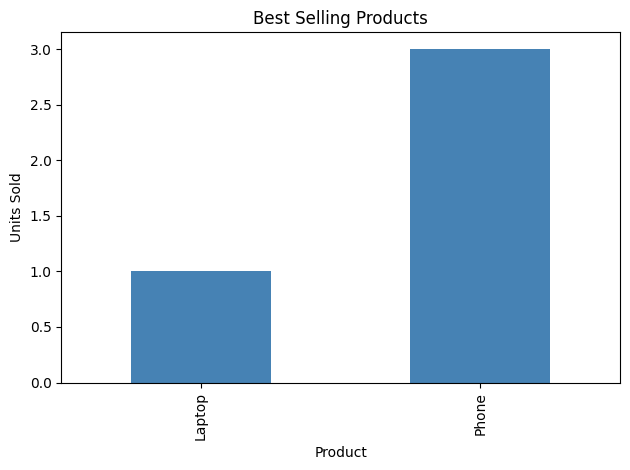

In [14]:
#Visualising the data using a bar chart showing total units sold per product
best_sellers.plot(
    kind='bar',
    x='name',
    y='total_sold',
    legend=False,
    color='steelblue'
)

plt.title('Best Selling Products')
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig('best_sellers.png')
plt.show